# Agent Based Models

Code examples from [Think Complexity, 2nd edition](https://thinkcomplex.com).

Copyright 2016 Allen Downey, [MIT License](http://opensource.org/licenses/MIT)

In [13]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from utils import decorate, savefig

In [14]:
def locs_where(condition):
    """Find cells where a logical array is True.
    
    condition: logical array
    
    returns: list of location tuples
    """
    return list(np.argwhere(condition))

## Discrepancy

In [24]:
from scipy.signal import correlate2d
from Cell2D import Cell2D, draw_array

from matplotlib.colors import LinearSegmentedColormap

# make a custom color map
palette = sns.color_palette('muted')
colors = 'white', palette[1], palette[0]
cmap = LinearSegmentedColormap.from_list('cmap', colors)


class Majority(Cell2D):
    """Represents a grid of Schelling agents."""
    
    options = dict(mode='same', boundary='wrap')

    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]]) / 8
    
    def __init__(self, n):
        """Initializes the attributes.

        n: number of rows
        p: threshold on the fraction of similar neighbors
        """
        self.red = np.random.uniform(1, 100, (n, n))
        self.blue = np.random.uniform(1, 100, (n, n))

    def count_neighbors(self):
        """Surveys neighboring cells.
        
        returns: tuple of
            empty: True where cells are empty
            frac_red: fraction of red neighbors around each cell
            frac_blue: fraction of blue neighbors around each cell
            frac_same: fraction of neighbors with the same color
        """
        red = self.red
        blue = self.blue

        ratio = self.red / (self.red + self.blue) * 100
        
        discrepancy = correlate2d(ratio, self.kernel, **self.options)
        
        locs = locs_where(np.abs(discrepancy) > 20)
        
        for loc in locs:
            print(loc)
        return discrepancy
    
    def step(self):
        """Executes one time step.
                
        returns: fraction of similar neighbors, averaged over cells
        """
        return self.count_neighbors()
        
    def draw(self):
        """Draws the cells."""
        draw_array(self.red, cmap='Reds', alpha=0.3, vmax=100)
        draw_array(self.blue, cmap='Blues', alpha=0.3, vmax=100)

Here's a small example.

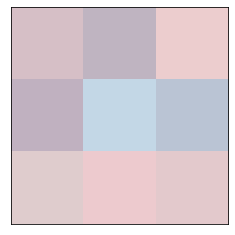

In [25]:
grid = Majority(n=3)
grid.draw()

In [26]:
grid.step()

[1 1]
[1 2]
[2 1]
[2 2]


array([[ 11.06608472,   5.00716876,  14.74706906],
       [ -4.25662316, -57.85760587, -42.07423947],
       [ -1.63601514,  34.00275477,  41.00140632]])

Suppose we want to multiply two 2-digit base-m numbers: x1 m + x2 and y1 m + y2:

1. compute x1 · y1, call the result F
2. compute x2 · y2, call the result G
3. compute (x1 + x2) · (y1 + y2), call the result H
4. compute H − F − G, call the result K; this number is equal to x1 · y2 + x2 · y1
5. compute F · m2 + K · m + G.

In [18]:
m = 10
m2 = m**2

def karatsuba_norec(x, y):
    x1, x2 = divmod(x, m)
    y1, y2 = divmod(y, m)
    F = x1 * y1 
    G = x2 * y2
    H = (x1 + x2) * (y1 + y2)
    K = H - F - G
    a = F * m2
    b = K * m
    return a + b + G

In [19]:
karatsuba_norec(123, 456)

56088

In [27]:
m = 10
m2 = m**2

def karatsuba(x, y):
    print(x, y)
    if x < m and y < m:
        return x * y
    
    x1, x2 = divmod(x, m)
    y1, y2 = divmod(y, m)
    F = karatsuba(x1, y1) 
    G = karatsuba(x2, y2)
    H = karatsuba(x1 + x2, y1 + y2)
    K = H - F - G
    a = F * m2
    b = K * m
    return a + b + G

In [28]:
karatsuba(123, 456)

123 456
12 45
1 4
2 5
3 9
3 6
15 51
1 5
5 1
6 6


56088

In [22]:
123 * 456

56088

In [1]:
d = {(True, False): 'fizz',
     (False, True): 'buzz',
     (True, True): 'fizzbuzz'}

for x in range(1, 101):
    t = (x%3==0, x%5==0)
    print(d.get(t, x))

1
2
fizz
4
buzz
fizz
7
8
fizz
buzz
11
fizz
13
14
fizzbuzz
16
17
fizz
19
buzz
fizz
22
23
fizz
buzz
26
fizz
28
29
fizzbuzz
31
32
fizz
34
buzz
fizz
37
38
fizz
buzz
41
fizz
43
44
fizzbuzz
46
47
fizz
49
buzz
fizz
52
53
fizz
buzz
56
fizz
58
59
fizzbuzz
61
62
fizz
64
buzz
fizz
67
68
fizz
buzz
71
fizz
73
74
fizzbuzz
76
77
fizz
79
buzz
fizz
82
83
fizz
buzz
86
fizz
88
89
fizzbuzz
91
92
fizz
94
buzz
fizz
97
98
fizz
buzz


In [12]:
x = np.arange(1, 101)
i = 2 * (x % 5 == 0) + (x%3 == 0)
np.choose(i, [x, 'fizz', 'buzz', 'fizzbuzz'])

array(['1', '2', 'fizz', '4', 'buzz', 'fizz', '7', '8', 'fizz', 'buzz',
       '11', 'fizz', '13', '14', 'fizzbuzz', '16', '17', 'fizz', '19',
       'buzz', 'fizz', '22', '23', 'fizz', 'buzz', '26', 'fizz', '28',
       '29', 'fizzbuzz', '31', '32', 'fizz', '34', 'buzz', 'fizz', '37',
       '38', 'fizz', 'buzz', '41', 'fizz', '43', '44', 'fizzbuzz', '46',
       '47', 'fizz', '49', 'buzz', 'fizz', '52', '53', 'fizz', 'buzz',
       '56', 'fizz', '58', '59', 'fizzbuzz', '61', '62', 'fizz', '64',
       'buzz', 'fizz', '67', '68', 'fizz', 'buzz', '71', 'fizz', '73',
       '74', 'fizzbuzz', '76', '77', 'fizz', '79', 'buzz', 'fizz', '82',
       '83', 'fizz', 'buzz', '86', 'fizz', '88', '89', 'fizzbuzz', '91',
       '92', 'fizz', '94', 'buzz', 'fizz', '97', '98', 'fizz'],
      dtype='<U21')